First, we load our datajoint config


In [2]:
from pathlib import Path
import datajoint as dj

dj.config.load(
    Path("dj_local_conf.json").absolute()
)  # replace with your config file name

[2026-06-22 13:38:23,679][INFO]: DataJoint is configured from /home/sgao/source/sgao_analysis/dj_local_conf.json


I have put all of our spike sorted data into a spike sorting group

In [11]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
SortedSpikesGroup()

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Bilbo20230724_.nwb,default_exclusion,04_lineartrack
Bilbo20230724_.nwb,default_exclusion,06_lineartrack
Bilbo20230724_.nwb,default_exclusion,08_lineartrack
Bilbo20230724_.nwb,default_exclusion,10_lineartrack
Bilbo20230724_.nwb,default_exclusion,12_lineartrack
Bilbo20230725_.nwb,default_exclusion,02_lineartrack
Bilbo20230725_.nwb,default_exclusion,04_lineartrack
Bilbo20230725_.nwb,default_exclusion,06_lineartrack
Bilbo20230725_.nwb,default_exclusion,08_lineartrack
Bilbo20230725_.nwb,default_exclusion,10_lineartrack


In [10]:
SortedSpikesGroup & {"nwb_file_name": "Caius20260618_.nwb"}

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Caius20260618_.nwb,exclude_all_other,mPFC_opto_testing


In [20]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

nwb_file_name = 'Caius20260618_.nwb'

group_key = {
    "nwb_file_name": nwb_file_name,
    "sorted_spikes_group_name":"mPFC_opto_testing",
}
SortedSpikesGroup & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Caius20260618_.nwb,exclude_all_other,mPFC_opto_testing


In [21]:
# here we can see that I put 3 sort groups (3 shanks in the mPFC) into this one sorted spikes group
SortedSpikesGroup.Units & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,spikesorting_merge_id
Caius20260618_.nwb,exclude_all_other,mPFC_opto_testing,be78ea95-effc-827a-5513-e1a9ce93e38e
Caius20260618_.nwb,exclude_all_other,mPFC_opto_testing,dd8284ca-87e1-8ec5-1d2a-2c870326c789
Caius20260618_.nwb,exclude_all_other,mPFC_opto_testing,e8ba80ce-a901-7712-c216-f94bfc5193d0


We can access the spikesorting results for this data using `SortedSpikesGroup.fetch_spike_data()`


In [3]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
group_key ={'nwb_file_name': 'Caius20260618_.nwb',
 'sorted_spikes_group_name': 'mPFC_opto_testing'}

[2026-06-22 14:38:31,685][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


In [4]:
# get the complete key
group_key = (SortedSpikesGroup & group_key).fetch1("KEY")
# get the spike data, returns a list of unit spike times
SortedSpikesGroup().fetch_spike_data(group_key)

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py

[array([1.78182174e+09, 1.78182174e+09, 1.78182174e+09, ...,
        1.78182553e+09, 1.78182553e+09, 1.78182553e+09]),
 array([1.78182174e+09, 1.78182174e+09, 1.78182174e+09, ...,
        1.78182554e+09, 1.78182554e+09, 1.78182554e+09]),
 array([1.78182174e+09, 1.78182174e+09, 1.78182174e+09, ...,
        1.78182554e+09, 1.78182554e+09, 1.78182554e+09]),
 array([1.78182177e+09, 1.78182180e+09, 1.78182180e+09, 1.78182180e+09,
        1.78182180e+09, 1.78182204e+09, 1.78182209e+09, 1.78182209e+09,
        1.78182209e+09, 1.78182209e+09, 1.78182210e+09, 1.78182210e+09,
        1.78182210e+09, 1.78182210e+09, 1.78182212e+09, 1.78182213e+09,
        1.78182215e+09, 1.78182216e+09, 1.78182216e+09, 1.78182216e+09,
        1.78182216e+09, 1.78182216e+09, 1.78182216e+09, 1.78182216e+09,
        1.78182217e+09, 1.78182217e+09, 1.78182217e+09, 1.78182218e+09,
        1.78182219e+09, 1.78182234e+09, 1.78182237e+09, 1.78182237e+09,
        1.78182237e+09, 1.78182260e+09, 1.78182264e+09, 1.78182264e

In [1]:
import pynwb

pynwb.__version__

'3.1.3'

Now we can get the cell spiking information

In [5]:
spike_times, unit_ids = SortedSpikesGroup().fetch_spike_data(
    group_key, return_unit_ids=True
)

In [6]:
len(unit_ids) #this is how many cells there are

# this is a lot probably because there are a lot of artifacts that looked like cells

 # so if the results look weird, we might have to do another round of curation

152

In [7]:
unit_ids #so each cell has a number and a spikesorting_merge_id so we can reference it in the database

[{'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 4},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 5},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 8},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 10},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 12},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 14},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 15},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 20},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 21},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 23},
 {'spikesorting_merge_id': UUID('e8ba80ce-a901-7712-c216-f94bfc5193d0'),
  'unit_id': 24},
 {

Now we want laser times

In [8]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Caius20260618.nwb", mode="r")
nwbf = io.read()

In [31]:
epoch_number = 0 # this goes from 0-9 and we can reference the google sheet to figure what laser power it is

epoch_start_time, epoch_stop_time, epoch_name = nwbf.intervals['epochs'][epoch_number].to_numpy()[0]

laser_data = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].data[:]
laser_timestamps = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].timestamps[:]

# Restrict to epoch
mask = (laser_timestamps > epoch_start_time) & (laser_timestamps <= epoch_stop_time)

laser_data_epoch = laser_data[mask]
laser_timestamps_epoch = laser_timestamps[mask]

# Ensure clean start
laser_data_epoch[0] = 0

# --- KEY STEP: only look at ON samples ---
laser_on_times_epoch = laser_timestamps_epoch[laser_data_epoch == 1]

# --- Detect first pulse of each train ---
first_laser_on_times = laser_on_times_epoch[
    np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)
]

I am just testing to see the number of spikes before and after a laser in session 1

In [11]:
unit = spike_times[1]
laser = first_laser_on_times[0]

window_spikes = unit[(unit > laser - 0.2) & (unit < laser + 0.2)]
print(window_spikes - laser)

[-0.06320071  0.03410029  0.07006741  0.07423425  0.07880068  0.0848341
  0.09826779]


I am checking neuron 0's activity in the entire first session before and after laser stim

In [16]:
unit = spike_times[0]   # choose one neuron
pre_counts = []
post_counts = []

for laser in first_laser_on_times:
    pre = np.sum((unit >= laser - 0.2) & (unit < laser))
    post = np.sum((unit >= laser) & (unit < laser + 0.2))

    pre_counts.append(pre)
    post_counts.append(post)

pre_avg = np.mean(pre_counts)
post_avg = np.mean(post_counts)
mi = (post_avg - pre_avg) / (post_avg + pre_avg)

print("pre avg:", pre_avg)
print("post avg:", post_avg)
print("modulation index:", mi)

pre avg: 0.1295843520782396
post avg: 0.09290953545232274
modulation index: -0.1648351648351648


Counting the individual modulation index and then average it

# Laser Power 0

In [32]:
mi_list = []

for unit in spike_times:

    pre_counts = []
    post_counts = []

    for laser in first_laser_on_times:
        pre = np.sum((unit >= laser - 0.2) & (unit < laser))
        post = np.sum((unit >= laser) & (unit < laser + 0.2))

        pre_counts.append(pre)
        post_counts.append(post)

    pre_avg = np.mean(pre_counts)
    post_avg = np.mean(post_counts)

    mi = (post_avg - pre_avg) / (post_avg + pre_avg + 1e-9)

    mi_list.append(mi)

mean_mi = np.mean(mi_list)

print("Number of neurons:", len(mi_list))
print("Mean MI:", mean_mi)

Number of neurons: 152
Mean MI: 0.0028050973665061075


Writing a loop to calculate the average modulation index within each laser power

In [44]:
epoch_mi = []

for epoch_number in range(10):

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time)
        & (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask]
    laser_timestamps_epoch = laser_timestamps[mask]

    laser_data_epoch[0] = 0

    laser_on_times_epoch = laser_timestamps_epoch[
        laser_data_epoch == 1
    ]

    first_laser_on_times = laser_on_times_epoch[
        np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)
    ]

    mi_list = []

    for unit in spike_times:

        pre_counts = []
        post_counts = []

        for laser in first_laser_on_times:
            pre = np.sum((unit >= laser - 0.2) & (unit < laser))
            post = np.sum((unit >= laser) & (unit < laser + 0.2))

            pre_counts.append(pre)
            post_counts.append(post)

        pre_avg = np.mean(pre_counts)
        post_avg = np.mean(post_counts)

        mi = (post_avg - pre_avg) / (post_avg + pre_avg + 1e-9)

        mi_list.append(mi)

    epoch_mi.append(np.mean(mi_list))

In [45]:
print(epoch_mi)

[0.0028050973665061075, -0.23841337384463354, -0.2378295550770252, -0.30271191404998743, -0.3846663310428358, -0.47956867672801395, -0.569861972411077, -0.6045970360219064, -0.5108977751997779, -0.4524800963853337]


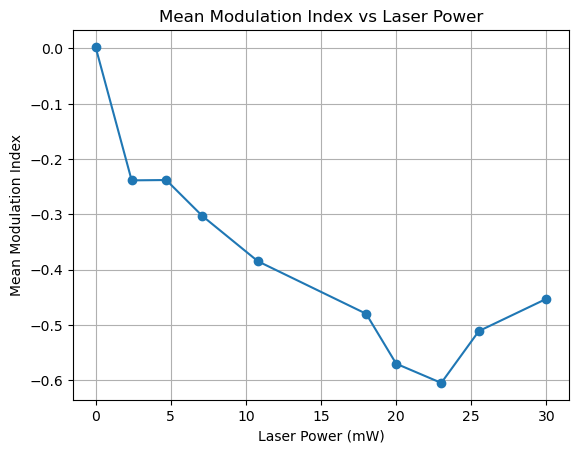

In [47]:
import matplotlib.pyplot as plt

laser_power = [0, 2.4, 4.7, 7.1, 10.8, 18, 20, 23, 25.5, 30]

plt.plot(laser_power, epoch_mi, marker='o')

plt.xlabel("Laser Power (mW)")
plt.ylabel("Mean Modulation Index")
plt.title("Mean Modulation Index vs Laser Power")

plt.grid(True)
plt.show()